# Sanity Check
This notebook verifies that the merged dataset was built correctly by running a series of consistency checks.

## Database Loading

Load the dataset from disk. This should complete without errors.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_PATH = "../data/processed/financial_database.parquet"

df = pd.read_parquet(DATA_PATH)

Preview the first rows to confirm columns and dtypes look reasonable.

In [59]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "ticker"]).reset_index(drop=True)

df.head()

,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_qoq,earnings_growth_qoq,fcf_growth_qoq,debt_to_equity,current_ratio,effective_date,macro_effective_date,CPIAUCSL,FEDFUNDS,GDP,ticker
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.201007,0.265057,0.321819,0.181691,0.075905,0.036521,0.223109,0.125321,0.092798,0.201176,0.316414,1.012057,2014-11-29,2015-01-01,NaN,0.11,NaN,AAPL
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021235,-0.026435,0.027455,0.509142,-0.042279,-0.010812,0.018854,0.064064,2.468254,-1.906542,0.383417,0.891085,2014-11-29,2015-01-01,NaN,0.11,NaN,AMZN
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.165769,0.225383,0.328572,0.131363,0.027718,0.021776,0.216486,0.035600,-0.182632,0.199933,0.053018,4.470703,2014-11-29,2015-01-01,NaN,0.11,NaN,GOOGL
3,2015-01-02,105.050003,105.550003,104.129997,104.519997,76.955574,5753600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.257161,0.301998,0.426653,0.139799,0.062005,0.035951,0.211350,-0.052731,0.097781,-0.168159,0.199332,2.609564,2014-11-29,2015-01-01,NaN,0.11,NaN,JNJ
4,2015-01-02,42.259998,42.400002,41.799999,42.139999,29.783411,9921100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.176520,0.226369,0.274132,0.124343,0.063239,0.021949,0.243904,-0.047558,-0.185356,0.034715,1.250710,1.082173,2014-11-29,2015-01-01,NaN,0.11,NaN,KO


## Initial Overview

### Shape, range and tickers

Check dataset size, expected date range (start of 2015 to end of 2025), and presence of all 10 tickers.

In [60]:
print("Shape:", df.shape)
print("Date Range:", df["date"].min().date(), "->", df["date"].max().date())
print("Number of Tickers:", df["ticker"].nunique())
print("Tickers:", sorted(df["ticker"].unique()))

Shape: (27650, 36)
Date Range: 2015-01-02 -> 2025-12-30
Number of Tickers: 10
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'KO', 'META', 'MSFT', 'NVDA', 'TSLA', 'XOM']


### Date continuity and frequency

Check per-ticker date gaps to confirm daily coverage and spot unusually long breaks.

In [86]:
df_sorted = df.sort_values(["ticker", "date"])
gaps = df_sorted.groupby("ticker")["date"].diff().dt.days

print("Gap (days) distribution:")
print(gaps.value_counts().sort_index().head(10))

largest_gaps = gaps.groupby(df_sorted["ticker"]).max().sort_values(ascending=False)
print("Largest gaps per ticker (days):")
display(largest_gaps.head(10))

suspicious = gaps[gaps > 4]
print("Gaps > 4 days:", suspicious.count())

Gap (days) distribution:
date
1.0    21630
2.0      270
3.0     4980
4.0      760
Name: count, dtype: int64
Largest gaps per ticker (days):


ticker
AAPL     4.0
AMZN     4.0
GOOGL    4.0
JNJ      4.0
KO       4.0
META     4.0
MSFT     4.0
NVDA     4.0
TSLA     4.0
XOM      4.0
Name: date, dtype: float64

Gaps > 4 days: 0


### Columns

Verify that the core OHLCV fields, `ticker`, and `date` are present and non-null.

In [67]:
expected_price_cols = ["open","high","low","close","adj_close","volume","ticker","date"]
missing = [c for c in expected_price_cols if c not in df.columns]
print("missing core cols:", missing)


missing core cols: []


Count the total number of columns and the distribution of dtypes.

In [68]:
print("num columns:", len(df.columns))
print(df.dtypes.value_counts())

num columns: 36
float64           31
datetime64[ns]     3
int64              1
object             1
Name: count, dtype: int64


Confirm the object column (`ticker`) and the datetime columns (the main `date` plus two auxiliary date fields).

In [78]:
column_types = df.dtypes
obj_cols = column_types[column_types == "object"]
date_cols = column_types[column_types == "datetime64[ns]"]

print("Object cols:", obj_cols.index.tolist())
print("Date cols:", date_cols.index.tolist())

Object cols: ['ticker']
Date cols: ['date', 'effective_date', 'macro_effective_date']


List the numeric columns to confirm which features are treated as numeric inputs.

In [80]:
df.select_dtypes(include=["number"]).columns.tolist()

['open',
 'high',
 'low',
 'close',
 'adj_close',
 'volume',
 'sma_50',
 'sma_200',
 'ema_20',
 'price_sma_50',
 'rsi_14',
 'macd',
 'macd_signal',
 'volatility_20d',
 'ret_1d',
 'ret_5d',
 'ret_21d',
 'net_margin',
 'operating_margin',
 'ebitda_margin',
 'asset_turnover',
 'roe',
 'roa',
 'fcf_margin',
 'revenue_growth_qoq',
 'earnings_growth_qoq',
 'fcf_growth_qoq',
 'debt_to_equity',
 'current_ratio',
 'CPIAUCSL',
 'FEDFUNDS',
 'GDP']

### Uniqueness and Duplicates

The `(date, ticker)` pair must be unique.

In [70]:
dups = df.duplicated(subset=["date", "ticker"]).sum()
print("duplicate rows on (date,ticker):", dups)

if dups > 0:
    display(df[df.duplicated(subset=["date","ticker"], keep=False)].head(20))


duplicate rows on (date,ticker): 0


### Panel structure

Validate the panel structure to confirm the long format (one row per `date` and `ticker`).

In [79]:
df[["date", "ticker"]].drop_duplicates().head(10)

,date,ticker
0,2015-01-02,AAPL
1,2015-01-02,AMZN
2,2015-01-02,GOOGL
3,2015-01-02,JNJ
4,2015-01-02,KO
5,2015-01-02,META
6,2015-01-02,MSFT
7,2015-01-02,NVDA
8,2015-01-02,TSLA
9,2015-01-02,XOM


### Panel Completeness

Each trading day should contain the full cross section of tickers (no missing tickers for a given date).

In [71]:
counts = df.groupby("date")["ticker"].nunique()
print("min tickers/day:", counts.min())
print("max tickers/day:", counts.max())
print("days with missing tickers:", (counts < counts.max()).sum())

# show worst days
display(counts[counts < counts.max()].head(10))

min tickers/day: 10
max tickers/day: 10
days with missing tickers: 0


Series([], Name: ticker, dtype: int64)

After checking daily ticker counts, summarize per-ticker coverage (first/last date and row count) to confirm consistent history.

In [84]:
# Compare each ticker's first/last date
coverage = df.groupby("ticker")["date"].agg(["min","max","count"]).sort_index()
coverage

,min,max,count
ticker,,,
AAPL,2015-01-02,2025-12-30,2765
AMZN,2015-01-02,2025-12-30,2765
GOOGL,2015-01-02,2025-12-30,2765
JNJ,2015-01-02,2025-12-30,2765
KO,2015-01-02,2025-12-30,2765
META,2015-01-02,2025-12-30,2765
MSFT,2015-01-02,2025-12-30,2765
NVDA,2015-01-02,2025-12-30,2765
TSLA,2015-01-02,2025-12-30,2765


2765 trading days are available, as shown above.

### NaN rates

Compute per-feature NaN rates and visualize only those above 1% to focus on the most affected features.

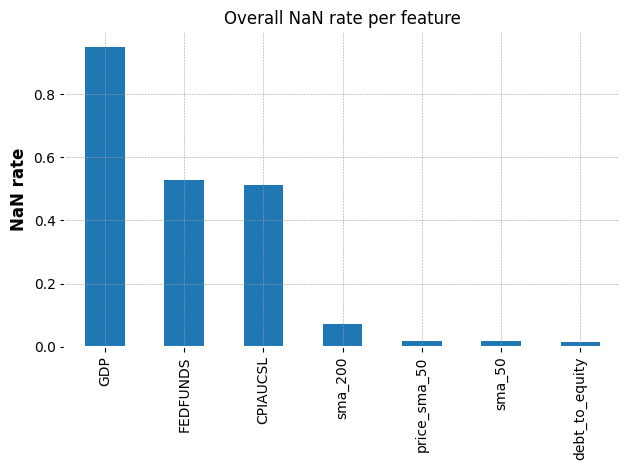

In [75]:
# %NaN per feature overall
overall_na = df.isna().mean().sort_values(ascending=False)

# Let's keep only those wirth a NaN rate of > 0.01
overall_na = overall_na[overall_na > 0.01]

plt.figure()
overall_na.plot(kind="bar")
plt.title("Overall NaN rate per feature")
plt.ylabel("NaN rate")
plt.tight_layout()
plt.show()


High NaN rates in macro features are expected because NaNs propagate during the merge when macro series are missing for a date; we will handle this explicitly in preprocessing. Similarly, moving-average features start with NaNs because rolling windows need a minimum lookback period before they can be computed.

### Leak Checks

Check for look-ahead leakage by verifying that any effective dates are not later than the observation date (and note missingness).

In [51]:
leak_checks = []

if "effective_date" in df.columns:
    ed = pd.to_datetime(df["effective_date"], errors="coerce")
    ok = (ed <= df["date"]).all()
    leak_checks.append(("effective_date<=date", ok, ed.isna().mean()))
    
if "macro_effective_date" in df.columns:
    med = pd.to_datetime(df["macro_effective_date"], errors="coerce")
    ok = (med <= df["date"]).all()
    leak_checks.append(("macro_effective_date<=date", ok, med.isna().mean()))

leak_checks


[('effective_date<=date', np.True_, np.float64(0.0)),
 ('macro_effective_date<=date', np.True_, np.float64(0.0))]

For each observation, firm-level fundamentals and macroeconomical data are only used after their public release date. This is enforced by requiring the effective publication date to be less than or equal to the observation date, thereby preventing any form of lookahead bias.

### Prices

Sanity-check price fields: no negative volume or non-positive prices, and review return distribution for extreme jumps.

volume negative: 0
adj_close <= 0: 0


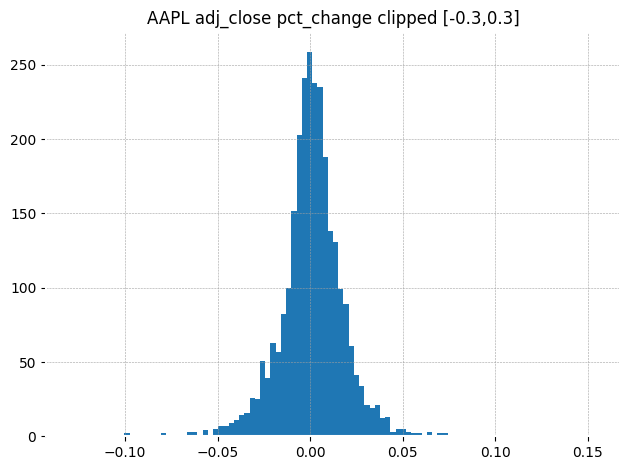

In [55]:
print("volume negative:", (df["volume"] < 0).sum())
print("adj_close <= 0:", (df["adj_close"] <= 0).sum())

# spot check extreme jumps (split adjustments etc.)
ticker = sorted(df["ticker"].unique())[0]
t = df[df["ticker"]==ticker].sort_values("date")
rets = t["adj_close"].pct_change()

plt.figure()
rets.clip(-0.3, 0.3).hist(bins=100)
plt.title(f"{ticker} adj_close pct_change clipped [-0.3,0.3]")
plt.tight_layout()
plt.show()


## Technical Data

### Returns Consistency

Validate that precomputed returns match `adj_close.pct_change()` with the expected shift. We check more than one ticker to avoid a single-case false positive.

In [92]:
tickers = sorted(df["ticker"].unique())
sample = tickers[:3] if len(tickers) >= 3 else tickers

for tkr in sample:
    t = df[df["ticker"] == tkr].sort_values("date")
    true_ret = t["adj_close"].pct_change(1)
    expected = true_ret.shift(1)
    diff = (t["ret_1d"] - expected).abs().dropna()
    print(f"{tkr} | mean abs diff: {diff.mean():.6f} | max abs diff: {diff.max():.6f}")


AAPL | mean abs diff: 0.000000 | max abs diff: 0.000000
AMZN | mean abs diff: 0.000000 | max abs diff: 0.000000
GOOGL | mean abs diff: 0.000000 | max abs diff: 0.000000


### Moving-Average Lags and NaNs

Start with trend indicators and confirm moving averages are properly lagged and that rolling indicators have more NaNs for longer windows (e.g., `sma_200` > `sma_50`).

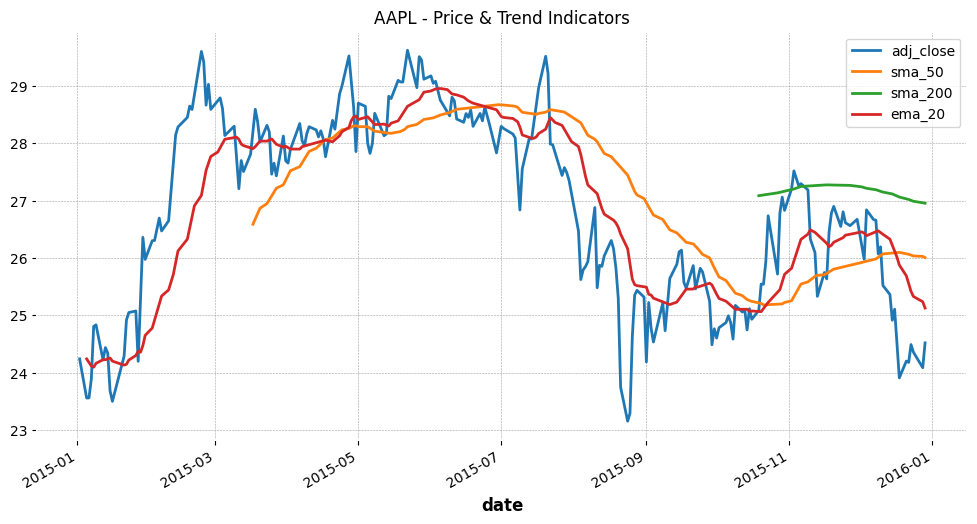

In [96]:
cols = [
    "adj_close",
    "sma_50",
    "sma_200",
    "ema_20",
]

aapl = df[df["ticker"]=="AAPL"].set_index("date")
aapl[cols].iloc[:250].plot(figsize=(12,6))
plt.title("AAPL - Price & Trend Indicators")
plt.show()

In [93]:
ma_cols = [c for c in ["sma_50", "sma_200", "ema_20"] if c in df.columns]
if ma_cols:
    na_rates = df[ma_cols].isna().mean().sort_values(ascending=False)
    display(na_rates)
else:
    print("No moving-average columns found.")


sma_200    0.072333
sma_50     0.018083
ema_20     0.000362
dtype: float64

### RSI and MACD Scale Check

Check momentum indicators:
- `rsi_14` within 0-100
- `macd` and `macd_signal` should be roughly centered around zero and within reasonable quantiles.

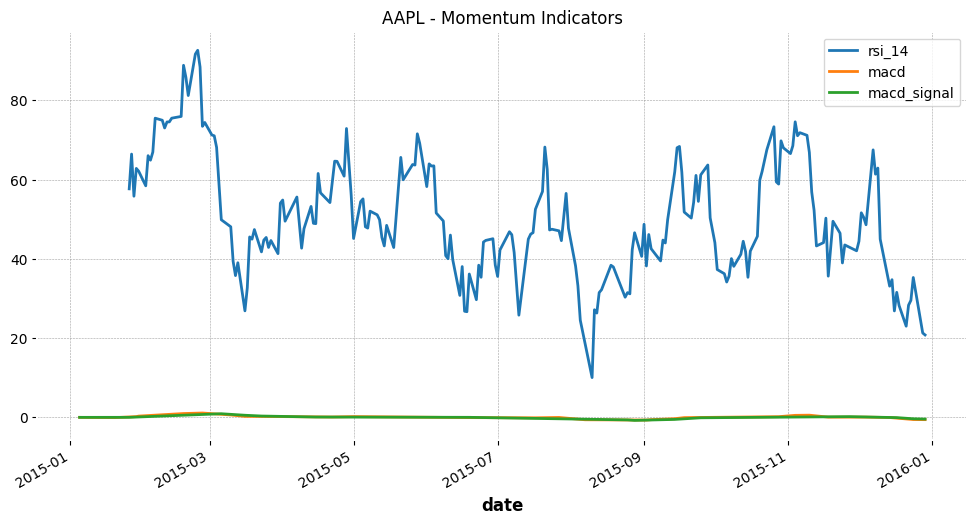

In [97]:
cols = [
    "rsi_14",
    "macd",
    "macd_signal",
]
aapl[cols].iloc[:250].plot(figsize=(12,6))
plt.title("AAPL - Momentum Indicators")
plt.show()

In [94]:
for c in ["macd", "macd_signal"]:
    if c in df.columns:
        s = df[c].dropna()
        if not s.empty:
            q = s.quantile([0.01, 0.5, 0.99])
            print(c, "quantiles:", q.to_dict())



macd quantiles: {0.01: -11.26836362821723, 0.5: 0.2743229986094491, 0.99: 15.880036987999555}
macd_signal quantiles: {0.01: -10.722012749388059, 0.5: 0.27454718850829707, 0.99: 15.19468324421715}


Quick recap: technical features look consistent across trend, momentum, and returns checks.

## Fundamental Data

### Quarterly update check

Fundamental features should update quarterly and be forward-filled after a reporting lag. We verify that values are piecewise-constant between effective dates (or detected change points) and that updates occur only after the expected lag, without leakage. We then sample segments to confirm values remain constant within each interval.

In [9]:
# Check that fundamentals are piecewise-constant between effective dates (forward-fill with lag)
fund_cols = ["net_margin", "roe", "debt_to_equity"]
fund_cols = [c for c in fund_cols if c in df.columns]

if not fund_cols:
    print("No fundamental columns found.")
else:
    # Use effective_date if present, otherwise approximate by change points in the first available fundamental
    ed_col = "effective_date" if "effective_date" in df.columns else None
    for tkr, t in df.sort_values(["ticker", "date"]).groupby("ticker"):
        t = t.copy()
        if ed_col:
            t[ed_col] = pd.to_datetime(t[ed_col], errors="coerce")
            change_points = sorted(t[ed_col].dropna().unique())
        else:
            print("No effective_date column found.")

        if not change_points:
            segments = [(t["date"].min(), t["date"].max())]
        else:
            segments = []
            for i, cp in enumerate(change_points):
                start = cp
                end = change_points[i + 1] if i + 1 < len(change_points) else t["date"].max()
                segments.append((start, end))

        for start, end in segments[:5]:
            seg = t[(t["date"] >= start) & (t["date"] < end)]
            for c in fund_cols:
                if seg[c].notna().any():
                    uniq = seg[c].dropna().nunique()
                    if uniq > 1:
                        print(f"{tkr} | {c} varies within segment {start} -> {end} (nunique={uniq})")
                        break


### Fundamental Coverage by Ticker

Count valid observations per ticker after the first non-NaN date to ensure coverage is not sparse.

In [31]:
if fund_cols:
    coverage = (
        df.sort_values("date")
          .groupby("ticker")[fund_cols]
          .apply(lambda g: g.notna().sum())
    )
    display(coverage)
else:
    print("No fundamental columns found.")

,net_margin,roe,debt_to_equity
ticker,,,
AAPL,2765,2765,2765
AMZN,2765,2765,2765
GOOGL,2765,2765,2765
JNJ,2765,2765,2765
KO,2765,2765,2765
META,2765,2765,2324
MSFT,2765,2765,2765
NVDA,2765,2765,2765
TSLA,2765,2765,2765


Looks correct. Next, confirm fundamentals vary across tickers (e.g., compare summary stats per ticker) to avoid replication errors.

In [101]:
df.groupby("ticker")["roe"].mean().sort_values()

ticker
TSLA    -0.028253
XOM      0.026857
AMZN     0.041587
GOOGL    0.053257
META     0.058733
JNJ      0.061599
MSFT     0.083610
KO       0.087330
NVDA     0.117075
AAPL     0.235479
Name: roe, dtype: float64

### Raw JSON Consistency

Cross-check `net_margin` against Alpha Vantage income statements by recomputing margins from quarterly reports and matching them to the segment effective dates (fiscal date + 60-day lag).

In [20]:
import json
from pathlib import Path

lag_days = 60
tickers = sorted(df["ticker"].unique())[:3]

for tkr in tickers:
    path = Path("../data/raw/alphavantage/income") / f"{tkr}.json"
    if not path.exists():
        print(tkr, "income json missing")
        continue

    data = json.loads(path.read_text())
    reports = data.get("quarterlyReports", [])
    rows = []
    for r in reports:
        fde = pd.to_datetime(r.get("fiscalDateEnding"), errors="coerce")
        if pd.isna(fde):
            continue
        net_income = pd.to_numeric(r.get("netIncome"), errors="coerce")
        total_rev = pd.to_numeric(r.get("totalRevenue"), errors="coerce")
        if pd.isna(net_income) or pd.isna(total_rev) or total_rev == 0:
            continue
        net_margin_raw = net_income / total_rev
        eff = fde + pd.Timedelta(days=lag_days)
        rows.append({"effective_date": eff, "net_margin_raw": net_margin_raw})

    rep = pd.DataFrame(rows).sort_values("effective_date")
    t = df[df["ticker"] == tkr].copy()
    if "effective_date" not in t.columns:
        print(tkr, "effective_date column missing")
        continue
    t["effective_date"] = pd.to_datetime(t["effective_date"], errors="coerce")
    merged = t.merge(rep, on="effective_date", how="left")
    diff = (merged["net_margin"] - merged["net_margin_raw"]).abs()
    ok_rate = (diff.dropna() < 1e-6).mean() if diff.notna().any() else float('nan')
    print(f"{tkr} | matched rows: {diff.notna().sum()} | ok rate: {ok_rate:.2f}")


AAPL | matched rows: 2765 | ok rate: 1.00
AMZN | matched rows: 2765 | ok rate: 1.00
GOOGL | matched rows: 2765 | ok rate: 1.00


## Macro Data

### Basic Macro Plots

Inspect the macro series plots.

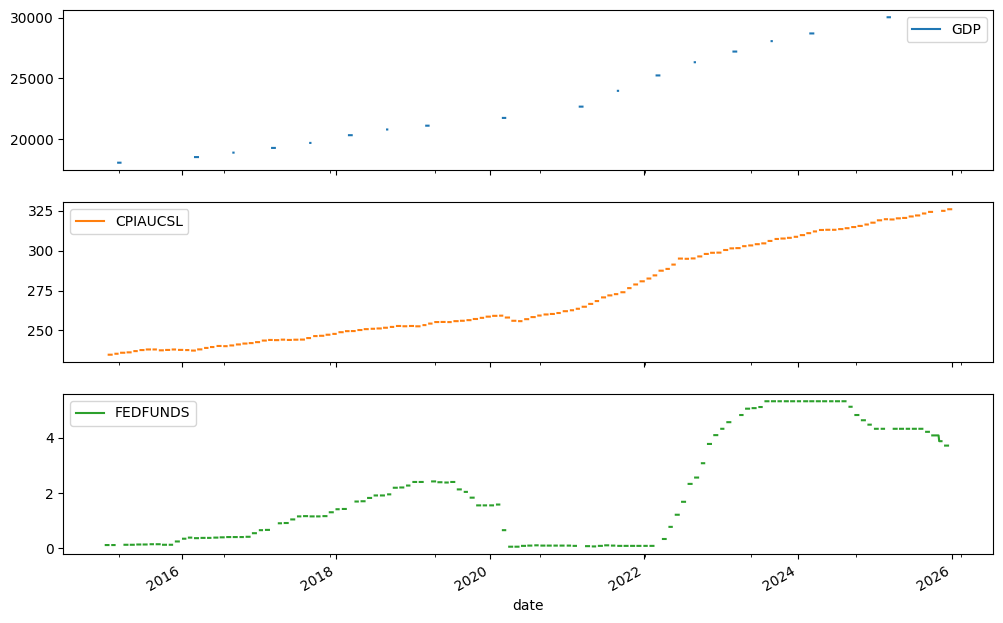

In [29]:
macro_cols = ["GDP", "CPIAUCSL", "FEDFUNDS"]
aapl = df[df["ticker"]=="AAPL"].set_index("date")
aapl_macro = aapl[macro_cols]

aapl_macro.plot(subplots=True, figsize=(12,8))
plt.show()

### Expected NaNs

In [ ]:
macro_na_rates = aapl_macro[macro_cols].isna().mean().sort_values(ascending=False)
display(macro_na_rates)

GDP         0.948282
FEDFUNDS    0.528752
CPIAUCSL    0.511392
dtype: float64

High NaN rates in macroeconomic variables are expected, as macro series are released at lower frequency and are aligned using publication-adjusted effective dates without forward propagation. These NaNs are resolved during preprocessing via forward-fill.

### Changing frequency of MACROS

Even thought most of them as still NaNs, we should see a change of the value of each macroeconomical indicator with the following lag and frequency:
- `GDP`-> every 3 months, with a lag of 60 days
- `CPI`-> every month, with a lag of 15 days
- `FEDFUNDS` -> every month, with a lag of 0 days

In [56]:
macro_cols = ["CPIAUCSL", "FEDFUNDS", "GDP"]
appl_macro = df[df["ticker"]=="AAPL"][["date"] + macro_cols]

for col in macro_cols:
  non_nan_dates = appl_macro[appl_macro[col].notna()]["date"].unique()
  old_val = None
  count = 0
  for date in non_nan_dates:
    val = appl_macro.loc[appl_macro["date"]==date, col].iloc[0]
    if old_val is not None and val != old_val:
      print(f"Value changed for {col} on {date.date()}: {old_val} -> {val}")
      count += 1
    old_val = val
    if count >= 7:
      print("...")
      break

Value changed for CPIAUCSL on 2015-02-17: 234.747 -> 235.342
Value changed for CPIAUCSL on 2015-03-16: 235.342 -> 235.976
Value changed for CPIAUCSL on 2015-04-16: 235.976 -> 236.222
Value changed for CPIAUCSL on 2015-05-18: 236.222 -> 237.001
Value changed for CPIAUCSL on 2015-06-16: 237.001 -> 237.657
Value changed for CPIAUCSL on 2015-07-16: 237.657 -> 238.034
Value changed for CPIAUCSL on 2015-08-17: 238.034 -> 238.033
...
Value changed for FEDFUNDS on 2015-04-01: 0.11 -> 0.12
Value changed for FEDFUNDS on 2015-06-01: 0.12 -> 0.13
Value changed for FEDFUNDS on 2015-08-03: 0.13 -> 0.14
Value changed for FEDFUNDS on 2015-10-01: 0.14 -> 0.12
Value changed for FEDFUNDS on 2015-12-01: 0.12 -> 0.24
Value changed for FEDFUNDS on 2016-01-04: 0.24 -> 0.34
Value changed for FEDFUNDS on 2016-02-01: 0.34 -> 0.38
...
Value changed for GDP on 2015-08-31: 18063.529 -> 18401.626
Value changed for GDP on 2015-11-30: 18401.626 -> 18435.137
Value changed for GDP on 2016-03-01: 18435.137 -> 18525.933
